In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pdm.data_loader import load_raw_data

sns.set_theme(style="whitegrid")
raw = load_raw_data("../data/raw/")
print("Data loaded successfully")

Data loaded successfully


In [2]:
for name, df in raw.items():
    date_range = f"{df['datetime'].min()} \u2192 {df['datetime'].max()}" if 'datetime' in df.columns else 'N/A'
    print(f"{name:12s}: {df.shape[0]:>7,} rows \u00d7 {df.shape[1]} cols | {date_range}")

telemetry   : 876,100 rows × 6 cols | 2015-01-01 06:00:00 → 2016-01-01 06:00:00
machines    :     100 rows × 3 cols | N/A
errors      :   3,919 rows × 3 cols | 2015-01-01 06:00:00 → 2016-01-01 05:00:00
maint       :   3,286 rows × 3 cols | 2014-06-01 06:00:00 → 2016-01-01 06:00:00
failures    :     761 rows × 3 cols | 2015-01-02 03:00:00 → 2015-12-31 06:00:00


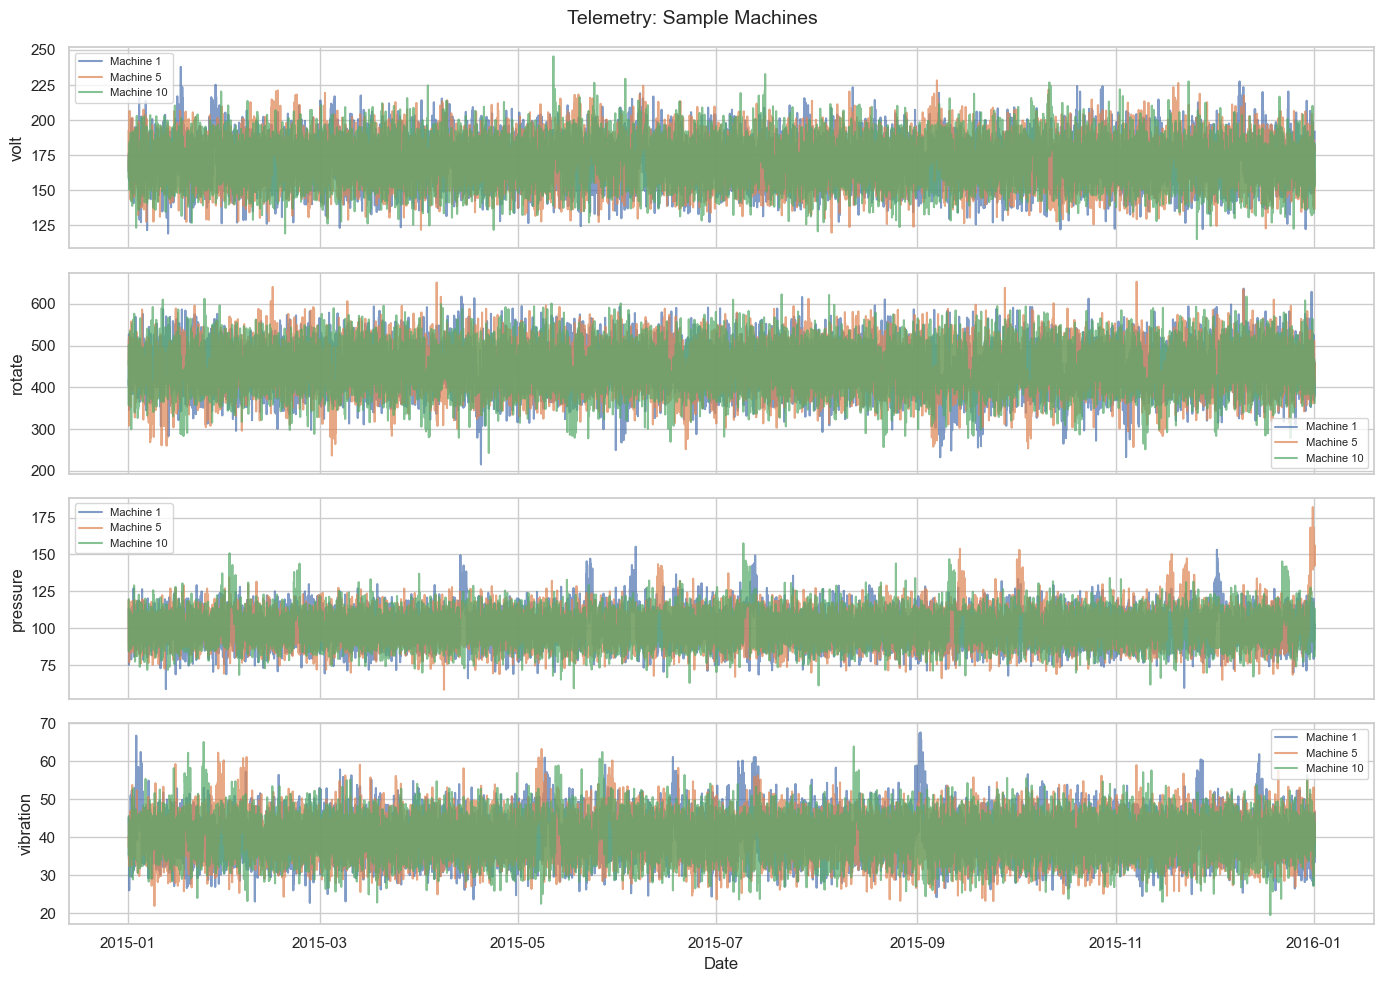

In [3]:
sample_machines = [1, 5, 10]
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
sensors = ["volt", "rotate", "pressure", "vibration"]
for ax, sensor in zip(axes, sensors):
    for mid in sample_machines:
        data = raw["telemetry"][raw["telemetry"]["machineID"] == mid]
        ax.plot(data["datetime"], data[sensor], alpha=0.7, label=f"Machine {mid}")
    ax.set_ylabel(sensor)
    ax.legend(fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("Telemetry: Sample Machines", fontsize=14)
plt.tight_layout()
plt.show()

Total failures: 761

Failures by component:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64


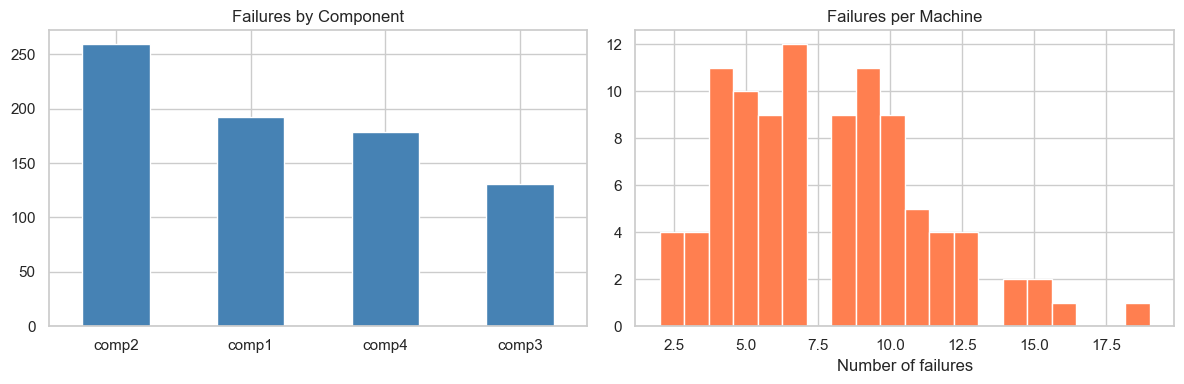

In [4]:
print(f"Total failures: {len(raw['failures'])}")
print(f"\nFailures by component:")
print(raw["failures"]["failure"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw["failures"]["failure"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Failures by Component")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

failures_per_machine = raw["failures"].groupby("machineID").size()
axes[1].hist(failures_per_machine, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Failures per Machine")
axes[1].set_xlabel("Number of failures")
plt.tight_layout()
plt.show()

In [5]:
from src.pdm.data_loader import build_base_dataframe
from src.pdm.labels import make_labels

base_df = build_base_dataframe(raw)
labels = make_labels(base_df, raw["failures"], horizon_hours=12)

n_pos = labels.sum()
n_neg = len(labels) - n_pos
print(f"Positive (failure within 12h): {n_pos:,} ({n_pos/len(labels):.2%})")
print(f"Negative:                       {n_neg:,} ({n_neg/len(labels):.2%})")
print(f"Imbalance ratio: 1:{int(n_neg/n_pos)}")

Positive (failure within 12h): 8,619 (0.98%)
Negative:                       867,481 (99.02%)
Imbalance ratio: 1:100


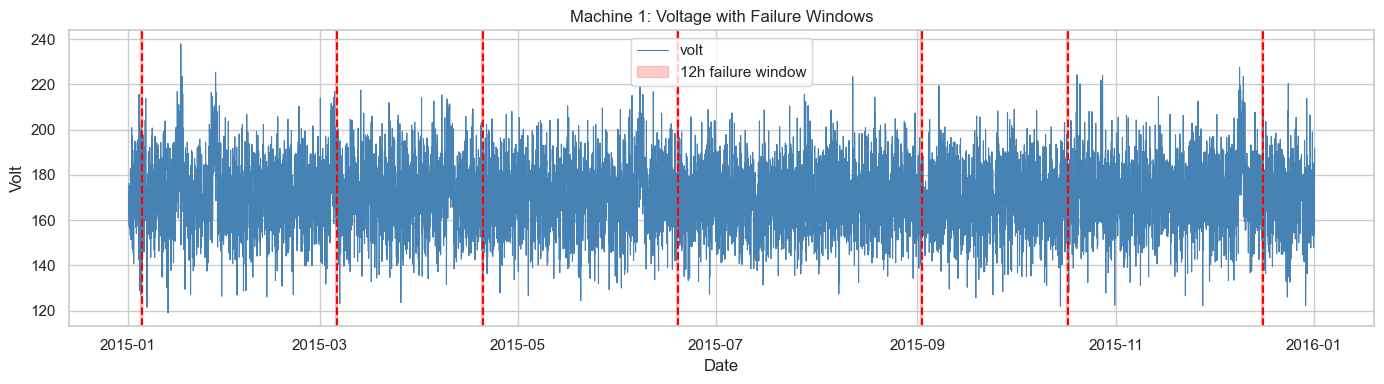

In [6]:
machine_id = 1
machine_df = base_df[base_df["machineID"] == machine_id].copy()
machine_failures = raw["failures"][raw["failures"]["machineID"] == machine_id]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(machine_df["datetime"], machine_df["volt"], lw=0.8, color="steelblue", label="volt")
for _, row in machine_failures.iterrows():
    ax.axvspan(row["datetime"] - pd.Timedelta(hours=12), row["datetime"],
               alpha=0.2, color="red", label="12h failure window")
    ax.axvline(row["datetime"], color="red", lw=1.5, linestyle="--")
ax.set_title(f"Machine {machine_id}: Voltage with Failure Windows")
ax.set_xlabel("Date")
ax.set_ylabel("Volt")
handles, lbls = ax.get_legend_handles_labels()
unique = dict(zip(lbls, handles))
ax.legend(unique.values(), unique.keys())
plt.tight_layout()
plt.show()